# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset yang digunakan dalam eksperimen ini adalah **Pistachio Dataset** yang diperoleh dari public repository. Dataset ini berisi data fitur citra dan atribut struktural dari dua jenis kacang pistachio yang berbeda, yaitu:
 **Kirmizi_Pistachio**
 **Siirt_Pistachio**

Tujuan dari eksperimen ini adalah melakukan klasifikasi untuk memprediksi jenis/varietas kacang pistachio berdasarkan fitur-fitur yang tersedia. Pada eksperimen ini, digunakan file `Pistachio_28_Features_Dataset.xlsx` yang memiliki 28 fitur klasifikasi.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
# Mengimport library dasar untuk analisis data dan visualisasi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Library tambahan untuk membaca file Excel
import openpyxl 

print("Library berhasil di-import!")

Library berhasil di-import!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Memuat dataset dari folder Pistachio_raw
# Jalur path disesuaikan dengan struktur folder lokal Anda
path_data = "../Pistachio_raw/Pistachio_28_Features_Dataset/Pistachio_28_Features_Dataset.xlsx"

# Membaca file excel menggunakan pandas
df = pd.read_excel(path_data)

# Menampilkan 5 baris pertama untuk memastikan data berhasil termuat
df.head()

,Area,Perimeter,Major_Axis,Minor_Axis,Eccentricity,Eqdiasq,Solidity,Convex_Area,Extent,Aspect_Ratio,...,StdDev_RR,StdDev_RG,StdDev_RB,Skew_RR,Skew_RG,Skew_RB,Kurtosis_RR,Kurtosis_RG,Kurtosis_RB,Class
0,63391,1568.405,390.3396,236.7461,0.7951,284.0984,0.8665,73160,0.6394,1.6488,...,17.7206,19.6024,21.1342,0.4581,0.6635,0.7591,2.9692,3.0576,2.9542,Kirmizi_Pistachio
1,68358,1942.187,410.8594,234.7525,0.8207,295.0188,0.8765,77991,0.6772,1.7502,...,26.7061,27.2112,25.1035,-0.3847,-0.2713,-0.2927,1.9807,2.1006,2.2152,Kirmizi_Pistachio
2,73589,1246.538,452.3630,220.5547,0.8731,306.0987,0.9172,80234,0.7127,2.0510,...,19.0129,20.0703,20.7006,-0.6014,-0.4500,0.2998,3.5420,3.6856,4.1012,Kirmizi_Pistachio
3,71106,1445.261,429.5291,216.0765,0.8643,300.8903,0.9589,74153,0.7028,1.9879,...,18.1773,18.7152,29.7883,-0.6943,-0.6278,-0.7798,2.8776,2.8748,2.8953,Kirmizi_Pistachio
4,80087,1251.524,469.3783,220.9344,0.8823,319.3273,0.9657,82929,0.7459,2.1245,...,23.4298,24.0878,23.1157,-0.9287,-0.8134,-0.4970,2.9915,2.8813,2.7362,Kirmizi_Pistachio


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [3]:
# 1. Memeriksa dimensi data (jumlah baris dan kolom)
print(f"Bentuk dataset (baris, kolom): {df.shape}")

# 2. Memeriksa tipe data setiap kolom dan mendeteksi nilai kosong awal
df.info()

Bentuk dataset (baris, kolom): (2148, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2148 entries, 0 to 2147
Data columns (total 29 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Area           2148 non-null   int64  
 1   Perimeter      2148 non-null   float64
 2   Major_Axis     2148 non-null   float64
 3   Minor_Axis     2148 non-null   float64
 4   Eccentricity   2148 non-null   float64
 5   Eqdiasq        2148 non-null   float64
 6   Solidity       2148 non-null   float64
 7   Convex_Area    2148 non-null   int64  
 8   Extent         2148 non-null   float64
 9   Aspect_Ratio   2148 non-null   float64
 10  Roundness      2148 non-null   float64
 11  Compactness    2148 non-null   float64
 12  Shapefactor_1  2148 non-null   float64
 13  Shapefactor_2  2148 non-null   float64
 14  Shapefactor_3  2148 non-null   float64
 15  Shapefactor_4  2148 non-null   float64
 16  Mean_RR        2148 non-null   float64
 17  Mean_RG   

In [4]:
# Mengambil statistik deskriptif untuk fitur-fitur numerik
df.describe()

,Area,Perimeter,Major_Axis,Minor_Axis,Eccentricity,Eqdiasq,Solidity,Convex_Area,Extent,Aspect_Ratio,...,Mean_RB,StdDev_RR,StdDev_RG,StdDev_RB,Skew_RR,Skew_RG,Skew_RB,Kurtosis_RR,Kurtosis_RG,Kurtosis_RB
count,2148.000000,2148.000000,2148.000000,2148.000000,2148.000000,2148.000000,2148.000000,2148.000000,2148.000000,2148.000000,...,2148.000000,2148.000000,2148.000000,2148.000000,2148.000000,2148.000000,2148.000000,2148.000000,2148.000000,2148.000000
mean,79950.655493,1425.971751,446.248968,238.311842,0.840219,317.919173,0.940093,85015.839851,0.716067,1.898154,...,191.995311,21.380084,22.591454,22.427056,-0.735243,-0.615580,-0.367142,3.054000,2.903015,2.940572
std,13121.737799,375.565503,32.445304,30.310695,0.048759,26.908600,0.050452,13154.919327,0.052532,0.240100,...,13.030505,3.127813,3.622222,3.926325,0.384584,0.389219,0.426964,0.733993,0.651383,0.750171
min,29808.000000,858.363000,320.344500,133.509600,0.504900,194.814600,0.588000,37935.000000,0.427200,1.158500,...,146.787600,10.611100,11.985400,11.197100,-1.931600,-1.658200,-2.348600,1.662400,1.665500,1.522500
25%,71936.750000,1170.996250,426.508750,217.875825,0.817500,302.642850,0.919850,76467.000000,0.687000,1.736375,...,182.930675,19.253550,20.036675,19.722425,-0.990900,-0.875975,-0.645800,2.509700,2.437400,2.449425
50%,79905.500000,1262.785500,448.574750,236.416350,0.849650,318.965300,0.954150,85075.500000,0.726500,1.896250,...,192.036350,21.425100,22.523250,22.276900,-0.756600,-0.653050,-0.424550,2.941750,2.807050,2.783350
75%,89030.500000,1607.906250,468.509400,257.760150,0.875200,336.685525,0.976925,93893.500000,0.753600,2.067025,...,201.097725,23.695900,25.241900,25.140125,-0.502500,-0.405000,-0.158400,3.446500,3.247400,3.224650
max,124008.000000,2755.049100,541.966100,383.046100,0.946000,397.356100,0.995100,132478.000000,0.820400,3.085800,...,235.000700,30.838300,33.614600,42.756600,1.865400,2.257600,1.852100,8.890600,10.453900,11.533900


In [5]:
# Memeriksa jumlah nilai kosong (null/missing values) di setiap kolom
missing_values = df.isnull().sum()
print("Jumlah nilai kosong di setiap kolom:")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "Tidak ada nilai kosong di seluruh kolom!")

Jumlah nilai kosong di setiap kolom:
Tidak ada nilai kosong di seluruh kolom!


Class
Kirmizi_Pistachio    1232
Siirt_Pistachio       916
Name: count, dtype: int64


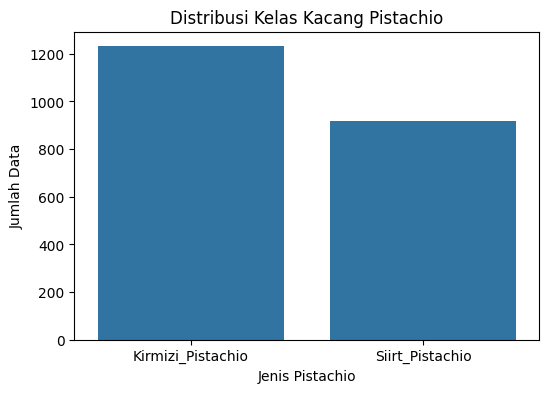

In [6]:
# Memeriksa jumlah data pada setiap kelas target
print(df['Class'].value_counts())

# Menampilkan visualisasi grafis batang untuk distribusi kelas
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Class')
plt.title('Distribusi Kelas Kacang Pistachio')
plt.xlabel('Jenis Pistachio')
plt.ylabel('Jumlah Data')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [7]:
# Memisahkan fitur (X) yaitu semua kolom kecuali 'Class'
X = df.drop(columns=['Class'])

# Memisahkan target (y) yaitu hanya kolom 'Class'
y = df['Class']

print("Fitur (X) dan Target (y) berhasil dipisahkan.")
print(f"Jumlah fitur: {X.shape[1]} kolom")

Fitur (X) dan Target (y) berhasil dipisahkan.
Jumlah fitur: 28 kolom


In [8]:
# Mengubah teks kelas menjadi angka (Kirmizi_Pistachio -> 0, Siirt_Pistachio -> 1)
y_encoded = y.map({'Kirmizi_Pistachio': 0, 'Siirt_Pistachio': 1})

print("Target berhasil di-encode!")
print("Contoh isi target setelah di-encode:")
print(y_encoded.value_counts())

Target berhasil di-encode!
Contoh isi target setelah di-encode:
Class
0    1232
1     916
Name: count, dtype: int64


In [9]:
# Mengimport fungsi untuk membagi data
from sklearn.model_selection import train_test_split

# Membagi data dengan proporsi 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print("Data berhasil dibagi menjadi Train Set dan Test Set!")
print(f"Jumlah data latihan (X_train): {X_train.shape[0]} baris")
print(f"Jumlah data pengujian (X_test): {X_test.shape[0]} baris")

Data berhasil dibagi menjadi Train Set dan Test Set!
Jumlah data latihan (X_train): 1718 baris
Jumlah data pengujian (X_test): 430 baris
